=== Cross-Margin Portfolio Exposure Results ===
Paths: 5000 | Steps: 24 | Horizon: 2.0 years
--------------------------------------------------------------------------------
Time(y)   EE(k USD)    PFE 97.5%(k USD)    EAD(k USD)
--------------------------------------------------------------------------------
  0.00     1082.87           1082.87          1516.01
  0.08     1089.36           1514.07          1525.10
  0.17     1095.33           1710.54          1533.46
  0.25     1105.85           1900.12          1548.19
  0.33     1118.75           2081.62          1566.25
  0.42     1127.93           2177.42          1579.10
  0.50     1141.50           2321.60          1598.10
  0.58     1149.70           2455.18          1609.58
  0.67     1158.58           2617.26          1622.01
  0.75     1165.99           2741.29          1632.39
  0.83     1173.77           2878.58          1643.28
  0.92     1187.43           2984.68          1662.40
  1.00     1197.14           3184.76       

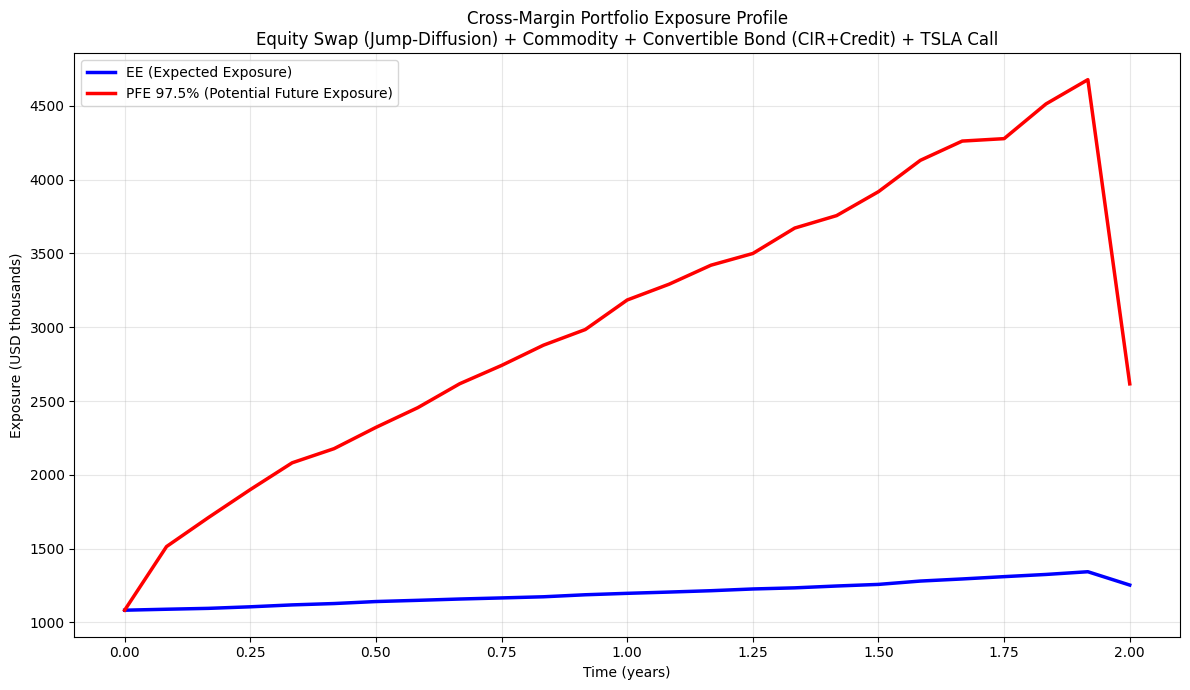


Chart saved as: cross_margin_exposure_profile.png


In [3]:
"""
Cross-Margin Counterparty Credit Risk Analysis
===============================================

Portfolio:
- Equity Swap (Merton Jump-Diffusion)
- Commodity Derivative (GBM)
- Convertible Bond (CIR + Credit Spread + Early Conversion Approximation)
- TSLA Call Option (Merton Jump-Diffusion)

Metrics: EE, PFE(97.5%), EAD
Author: Yongchao Huang
Date: April 2026
"""

import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import math

# ====================== 1. Common Market Parameters ======================
r0 = 0.03                    # Initial risk-free rate
q_tsla = 0.0                 # TSLA dividend yield
y_comm = 0.0                 # Commodity convenience yield
S0 = 250.0                   # Initial TSLA price
C0 = 80.0                    # Initial commodity price
sigma_s = 0.35               # TSLA diffusion volatility
sigma_c = 0.30               # Commodity volatility
rho_sc = 0.25                # Correlation between TSLA and commodity

# ====================== Merton Jump-Diffusion Parameters (TSLA-related products) ======================
lambda_j = 0.5               # Annual jump intensity
mu_j = -0.05                 # Jump size mean (log)
sigma_j = 0.15               # Jump size volatility
k = np.exp(mu_j + 0.5 * sigma_j**2) - 1   # Jump compensator

# ====================== CIR Stochastic Interest Rate Parameters ======================
kappa = 0.3
theta = 0.04
sigma_r = 0.08

# ====================== Convertible Bond Credit Risk Parameters ======================
credit_spread = 0.01         # 100bps credit spread

# ====================== Product-Specific Parameters ======================
# Equity Swap
N_swap = 1_000_000.0
T_swap = 2.0
fixed_rate_swap = 0.05

# Commodity Derivative
M_comm = 10_000.0
T_comm = 2.0

# Convertible Bond
face_cb = 1_000_000.0
T_cb = 3.0
coupon_rate = 0.02
conversion_ratio = 3000.0
conv_price = face_cb / conversion_ratio

# TSLA Call Option
T_opt = 1.5
K_opt = 260.0
notional_opt = 1000

# ====================== Simulation Parameters ======================
T_max = 2.0
N_steps = 24                 # Monthly steps
dt = T_max / N_steps
N_paths = 5000
np.random.seed(42)

# ====================== Generate Correlated Paths and Jumps ======================
Z = np.random.normal(0, 1, size=(N_paths, N_steps, 3))
corr_matrix = np.array([[1.0, rho_sc, 0.0],
                        [rho_sc, 1.0, 0.0],
                        [0.0, 0.0, 1.0]])
L = np.linalg.cholesky(corr_matrix)
dW = np.sqrt(dt) * (Z @ L.T)

N_jumps = np.random.poisson(lambda_j * dt, size=(N_paths, N_steps))
J = np.exp(mu_j + sigma_j * np.random.normal(0, 1, size=(N_paths, N_steps)))

# Initialize paths
S = np.zeros((N_paths, N_steps + 1)); S[:, 0] = S0
C = np.zeros((N_paths, N_steps + 1)); C[:, 0] = C0
r_path = np.zeros((N_paths, N_steps + 1)); r_path[:, 0] = r0

for i in range(N_steps):
    # TSLA: Merton Jump-Diffusion
    drift_s = (r0 - q_tsla - lambda_j * k) * dt
    S[:, i+1] = S[:, i] * np.exp(drift_s + sigma_s * dW[:, i, 0]) * (J[:, i] ** N_jumps[:, i])

    # Commodity: GBM
    mu_c = r0 - y_comm
    C[:, i+1] = C[:, i] * np.exp((mu_c - 0.5*sigma_c**2)*dt + sigma_c * dW[:, i, 1])

    # CIR Interest Rate
    r_temp = r_path[:, i] + kappa*(theta - r_path[:, i])*dt + \
             sigma_r * np.sqrt(np.maximum(r_path[:, i], 0.001)) * dW[:, i, 2]
    r_path[:, i+1] = np.maximum(r_temp, 0.001)

times = np.linspace(0, T_max, N_steps + 1)

# ====================== Valuation Helper Functions ======================
def bs_call(S, K, tau, r, sigma, q=0.0):
    if tau <= 1e-6:
        return np.maximum(S - K, 0.0)
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * np.exp(-q*tau) * norm.cdf(d1) - K * np.exp(-r*tau) * norm.cdf(d2)

def merton_call(S, K, tau, r, sigma, lam, muj, sigmaj, q=0.0, n_terms=30):
    if tau <= 1e-6:
        return np.maximum(S - K, 0.0)
    price = np.zeros_like(S, dtype=float)
    lam_prime = lam * np.exp(muj + 0.5*sigmaj**2)
    for n in range(n_terms):
        pn = np.exp(-lam_prime * tau) * (lam_prime * tau)**n / math.factorial(n)
        sigma_n = np.sqrt(sigma**2 + n * sigmaj**2 / tau)
        r_n = r - lam * k + (n / tau) * (muj + 0.5 * sigmaj**2)
        price += pn * bs_call(S, K, tau, r_n, sigma_n, q)
    return price

def cir_zero_bond(r_t, tau, kappa, theta, sigma_r):
    if tau <= 1e-6:
        return np.ones_like(r_t)
    gamma = np.sqrt(kappa**2 + 2 * sigma_r**2)
    denom = (gamma + kappa) * (np.exp(gamma * tau) - 1) + 2 * gamma
    b = 2 * (np.exp(gamma * tau) - 1) / denom
    a = (2 * kappa * theta / sigma_r**2) * np.log(2 * gamma * np.exp((kappa + gamma) * tau / 2) / denom)
    return np.exp(a - b * r_t)

# ====================== Product Valuation Functions ======================
def v_swap(S_t, t, r_t):
    tau = max(T_swap - t, 0)
    if tau <= 1e-6:
        return np.zeros_like(S_t)
    df = cir_zero_bond(r_t, tau, kappa, theta, sigma_r)
    forward_perf = (S_t / S0) * np.exp((r0 - q_tsla) * tau)
    payoff = forward_perf - 1 - fixed_rate_swap * T_swap
    return df * N_swap * payoff

def v_comm(C_t, t, r_t):
    tau = max(T_comm - t, 0)
    if tau <= 1e-6:
        return np.zeros_like(C_t)
    df = cir_zero_bond(r_t, tau, kappa, theta, sigma_r)
    F = C_t * np.exp((r0 - y_comm) * tau)
    K = C0 * np.exp((r0 - y_comm) * T_comm)
    return df * M_comm * (F - K)

def v_cb(S_t, t, r_t):
    tau = max(T_cb - t, 0)
    if tau <= 1e-6:
        return np.full_like(S_t, face_cb)
    # Discount with credit spread
    df = cir_zero_bond(r_t, tau, kappa, theta, sigma_r) * np.exp(-credit_spread * tau)
    # Straight bond part
    annuity = coupon_rate * face_cb * (1 - df) / (r0 + credit_spread)
    straight = annuity + face_cb * df
    # European conversion option (Merton)
    opt_val = conversion_ratio * merton_call(S_t, conv_price, tau, r0, sigma_s, lambda_j, mu_j, sigma_j, q_tsla)
    continuation = straight + opt_val
    # Early conversion approximation
    conversion_value = conversion_ratio * S_t
    return np.maximum(conversion_value, continuation)

def v_call(S_t, t):
    tau = max(T_opt - t, 0)
    return notional_opt * merton_call(S_t, K_opt, tau, r0, sigma_s, lambda_j, mu_j, sigma_j, q_tsla)

# ====================== Portfolio Exposure Calculation ======================
V_port = np.zeros((N_paths, N_steps + 1))
for step in range(N_steps + 1):
    t = times[step]
    S_t = S[:, step]
    C_t = C[:, step]
    r_t = r_path[:, step]
    V_port[:, step] = (v_swap(S_t, t, r_t) + 
                       v_comm(C_t, t, r_t) + 
                       v_cb(S_t, t, r_t) + 
                       v_call(S_t, t))

exposure = np.maximum(V_port, 0.0)
EE = np.mean(exposure, axis=0)
PFE = np.percentile(exposure, 97.5, axis=0)
EAD = 1.4 * EE

# ====================== Results Table ======================
print("=== Cross-Margin Portfolio Exposure Results ===")
print(f"Paths: {N_paths} | Steps: {N_steps} | Horizon: {T_max} years")
print("-" * 80)
print("Time(y)   EE(k USD)    PFE 97.5%(k USD)    EAD(k USD)")
print("-" * 80)
for i in range(len(times)):
    print(f"{times[i]:6.2f}   {EE[i]/1000:9.2f}      {PFE[i]/1000:12.2f}       {EAD[i]/1000:10.2f}")

print(f"\nMaximum EE : {np.max(EE)/1000:.2f} k USD")
print(f"Maximum PFE: {np.max(PFE)/1000:.2f} k USD")

# ====================== Plot Exposure Profile ======================
plt.figure(figsize=(12, 7))
plt.plot(times, EE/1000, 'b-', linewidth=2.5, label='EE (Expected Exposure)')
plt.plot(times, PFE/1000, 'r-', linewidth=2.5, label='PFE 97.5% (Potential Future Exposure)')
plt.xlabel('Time (years)')
plt.ylabel('Exposure (USD thousands)')
plt.title('Cross-Margin Portfolio Exposure Profile\n'
          'Equity Swap (Jump-Diffusion) + Commodity + Convertible Bond (CIR+Credit) + TSLA Call')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cross_margin_exposure_profile.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nChart saved as: cross_margin_exposure_profile.png")